____
# Sea state dependency


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import put_fig_letter, update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_variance, compute_variance_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
dt=12
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('12h', drifter_preprocess, drifter_preprocess_param)

In [3]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [base_dic]
l = ['L3-2km',]
ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [base_dic]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DS = DS.where((DS.ggde<1.5e-4) & (DS.ggdn<1.5e-4), drop=True)
DS = DS.where(DS.distance_to_coast>10e3, drop=True)

# Closure figs
ds = compute_variance(DS)/U2
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')


321898
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
321898
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


_______
# Compute and project (x = cross, y = alg)

In [4]:
# rotate
def rotate(e, n, phi):
    return np.cos(phi)*e - np.sin(phi)*n, np.sin(phi)*e + np.cos(phi)*n

def crossalg_proj(dsen):
    ds = dsen.copy()
    ds['sumx'] , ds['sumy'] = rotate(dsen.sume, dsen.sumn, dsen.phi)
    dsxy = ds[['sumx','sumy']]
    var = ['acc', 'cor', 'ggd', 'wd', 'sum']
    prod  = [l for l in ds.keys() if 'prodn' in l]
    exc  = [l for l in ds.keys() if 'excn' in l]
    for v in var :
        dsxy[v +'x'] , dsxy[v +'y'] = rotate(dsen[v+'e'], dsen[v+'n'], dsen.phi)

    for direction in ['x', 'y'] : 
            if direction == 'x' : l = {'acc':'accx', 'cor':'corx', 'ggd':'ggdx', 'wd':'wdx'}
            if direction == 'y' : l = {'acc':'accy', 'cor':'cory', 'ggd':'ggdy', 'wd':'wdy'}
                
            # sum 
            dsxy['sum'+direction] = sum([dsxy[l[v]] for v in l])
            
            # simple var + sum- one term
            for v in l :
                dsxy[l[v]] = dsxy[l[v]]
                dsxy['exc'+direction+'_'+v] = dsxy['sum'+direction]-dsxy[l[v]]
                
            #2 by 2 product    
            import itertools  
            couple = list(itertools.combinations(list(l.keys()),2))
            for c in couple : 
                dsxy['prod'+direction+'_'+'_'.join(c)] = dsxy[c[0]+direction] * dsxy[c[1]+direction]
    return dsxy
    
DSr =  crossalg_proj(DS)  

In [5]:
DSr

<xarray.Dataset> Size: 102MB
Dimensions:            (id_comb: 1, row_number: 302667)
Coordinates: (12/13)
    datetime           (id_comb, row_number) datetime64[ns] 2MB 2023-03-28T12...
    longitude          (id_comb, row_number) float64 2MB 5.672 5.671 ... 1.739
    latitude           (id_comb, row_number) float64 2MB 42.93 42.93 ... 38.39
    pass_number        (id_comb, row_number) int64 2MB 3 3 3 3 3 ... 16 16 16 16
    time_to_swot       (id_comb, row_number) timedelta64[ns] 2MB 11:50:02.155...
    cycle_number       (id_comb, row_number) int64 2MB 474 474 474 ... 577 577
    ...                 ...
    drifter_type       (id_comb, row_number) object 2MB 'CARTHE' ... 'SVP'
    depth              (id_comb, row_number) int64 2MB 0 0 0 0 0 ... 15 15 15 15
    phi                (id_comb, row_number) float64 2MB 0.2504 0.2504 ... 2.911
    distance_to_coast  (row_number) float64 2MB 1.753e+04 ... 3.296e+04
  * row_number         (row_number) int64 2MB 0 1 2 3 ... 377395 377396 377397
  * id_comb            (id_comb) <U6 24B 'L3-2km'
Data variables: (12/30)
    sumx               (id_comb, row_number) float64 2MB -2.503e-07 ... -9.60...
    sumy               (id_comb, row_number) float64 2MB -1.464e-06 ... 1.539...
    accx               (id_comb, row_number) float64 2MB -1.377e-06 ... -1.39...
    accy               (id_comb, row_number) float64 2MB 1.254e-06 ... 8.5e-06
    corx               (id_comb, row_number) float64 2MB -1.283e-06 ... 8.461...
    cory               (id_comb, row_number) float64 2MB -2.174e-05 ... -3.22...
    ...                 ...
    prody_acc_cor      (id_comb, row_number) float64 2MB -2.727e-11 ... -2.73...
    prody_acc_ggd      (id_comb, row_number) float64 2MB 2.445e-11 ... 6.004e-11
    prody_acc_wd       (id_comb, row_number) float64 2MB -5.904e-13 ... 1.26e-12
    prody_cor_ggd      (id_comb, row_number) float64 2MB -4.238e-10 ... -2.27...
    prody_cor_wd       (id_comb, row_number) float64 2MB 1.023e-11 ... -4.776...
    prody_ggd_wd       (id_comb, row_number) float64 2MB -9.176e-12 ... 1.047...

In [6]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x],coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    
    fig = plt.figure(figsize=(9, 4))
    
    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )
    
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    

    
    da.plot(ax=ax, add_colorbar=False)
    #da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    #ax.plot(xx, -xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )


    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title('')
    ax_histx.set_title('')
    ax_histy.set_xlabel('')
    ax_histx.set_xlabel('')
    fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

In [7]:
dfr = DSr.to_dataframe().reset_index().set_index('row_number')
dfs = pd.read_csv(os.path.join(zarr_dir, 'coloc_files', 'alti',f'alticoloc_{alti_product_key}_general_'+colocs_sources+'.csv')).set_index('row_number')
dfs['abs_cross_track_distance'] = abs(dfs['cross_track_distance'])

dfrr = pd.concat([dfs[['swh_model', 'abs_cross_track_distance', 'ssh_karin_uncert']], dfr], axis=1).dropna()

dss = dfrr.to_xarray()
#plot_join_pdfs(dss, 'swh_model', 'abs_cross_track_distance', binx=100, biny=100)

Text(0, 0.5, 'Number of colocations')

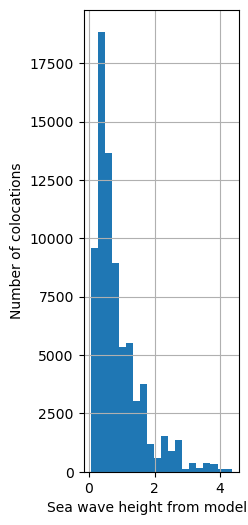

In [8]:
fig, ax = plt.subplots(1,1, figsize = (2, 6), frameon=False)
dfrr[dfrr.time_to_swot/pd.Timedelta('1h')<3].swh_model.hist(ax=ax, bins=20)
ax.set_xlabel('Sea wave height from model [m]')
ax.set_ylabel('Number of colocations')

In [9]:
def compute_mean_square_groupby(df, groupby = 'time_to_swot_1h', dirname = ('e', 'n'), compute_error = 'no', vars_errors=None):
    """ Compute closure stats on bins
    ds : dataset containing terms values for all row_numbers
    groupby : str, name of the binning variable
    dirname : directions of the reconstruction
    bootstrap :  bool, rather to compute bootstrap errors or not (longer with)
    """
    var = ['acc', 'cor', 'ggd', 'wd','sum']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']

    dff = (df[[v+dirname[1] for v in var] + [v+dirname[0] for v in var]]**2).rename(columns = {var[i]+dirname[1] : VAR[i]+dirname[1] for i in range(len(var))}).rename(columns = {var[i]+dirname[0] : VAR[i]+dirname[0] for i in range(len(var))})/U2
    dff = pd.concat([dff, df[groupby]], axis=1)
    
    nb_coloc = df.set_index(groupby).groupby(groupby, observed=False)['acc'+dirname[0]].count()

    #Balanced and error
    for direction in [dirname[0], dirname[1]]:
        dff['sigma'+direction] = dff['ACC'+direction] + dff['COR'+direction] + dff['GGD'+direction] + dff['WD'+direction]
        for v in ['acc', 'cor', 'ggd', 'wd'] : 
                dff['B'+direction+'_'+v] = -((df[v+direction]*df['exc'+direction+'_'+v]))/U2
                dff['E'+direction+'_'+v] = ((df[v+direction]*df['sum'+direction]))/U2
    #pairs contributions
    for v in [v for v in df if 'prod' in v]:
        dff[v.replace('prod', 'X')]=-2*df[v]/U2

    # Cyclo/anticyclo contribution
    for direction in [dirname[0], dirname[1]]:
        dff['D'+direction+'_cyclo'] = (-2 *(df['acc'+direction]+df['cor'+direction])*df['ggd'+direction])/U2
        dff['D'+direction+'_anticyclo'] = (-2 *(df['acc'+direction]+df['ggd'+direction])*df['cor'+direction])/U2

    #Sum of both direction
    for v in closure_vars :
        dff[v.replace('*', '')] = dff[v.replace('*', dirname[0])] + dff[v.replace('*', dirname[1])]

    closure_vars_2D = [v.replace('*', dirname[0]) for v in closure_vars] + [v.replace('*', dirname[1]) for v in closure_vars] + [v.replace('*', '')for v in closure_vars]
    
    if isinstance(groupby, str) : grp = [groupby]
    else : grp = groupby
    
    # centrallimit errors
    if compute_error == 'centrallimit' : 
        def compute_freedom_degree(df):
            return len(df.reset_index().groupby(['drifter_id', 'cycle_number', 'pass_number']).count())
        # effective freedom degree
        effective_degree = df.set_index(groupby).groupby(groupby, observed=False).apply(compute_freedom_degree)
        print(effective_degree)
        # Add errors central limit
        centrallimit = 2*dff.set_index(groupby).groupby(groupby, observed=False)[closure_vars_2D].std().div(np.sqrt(effective_degree), axis=0) # 95%
        centrallimit = centrallimit.rename(columns = {v:'er__'+v for v in closure_vars_2D})

    
    # bootstrap errors
    if compute_error == 'bootstrap' : 
        #print(vars_errors)
        if vars_errors is None : vars_errors = closure_vars_2D
        #import dask.dataframe as dd
        #dfd = dd.from_pandas(dff, chunksize=10)
        DF = []
        #print(vars_errors)
        for v in vars_errors:
            DF.append(
                dff.reset_index()[vars_errors + grp]#dfd
                .groupby(groupby, observed=False)[v]
                .apply(compute_bootstrap_error)
                #.compute()
            )
            print(v)
        booterrors = pd.concat(DF, axis=1)*2
        booterrors = booterrors.rename(columns={v: "er__" + v for v in booterrors.columns})
        # sum of both dim
        for v in vars_errors : 
            booterrors['er__'+v.replace('*', '')] = booterrors['er__'+v.replace('*', dirname[0])] + booterrors['er__'+v.replace('*', dirname[1])]
    
    #Final steps
    dff = dff.set_index(groupby)[closure_vars_2D].groupby(groupby, observed=False).mean()
    dff['nb_coloc']= nb_coloc

    for v in closure_vars : 
        dff[v.replace('*', '')] = dff[v.replace('*', dirname[0])] + dff[v.replace('*', dirname[1])]
    
    if compute_error == 'centrallimit' : 
        dff = pd.concat([dff, centrallimit], axis=1)
    if compute_error == 'bootstrap' :
        dff = pd.concat([dff, booterrors], axis=1)
        
        
    dss = dff.to_xarray()

    dss = assign_attrs(dss, dirname)
    #dss.to_netcdf(os.path.join(zarr_dir, 'binned_diag', '_'.join(grp) + '.png'))

    return dss
from diagnosis import closure_vars, assign_attrs

_________
# Regular bins

In [43]:
dfswh.columns

Index(['swh_model', 'abs_cross_track_distance', 'ssh_karin_uncert', 'id_comb',
       'sumx', 'sumy', 'datetime', 'longitude', 'latitude', 'pass_number',
       'time_to_swot', 'cycle_number', 'drifter_id', 'drifter_type', 'depth',
       'phi', 'distance_to_coast', 'accx', 'accy', 'corx', 'cory', 'ggdx',
       'ggdy', 'wdx', 'wdy', 'excx_acc', 'excx_cor', 'excx_ggd', 'excx_wd',
       'prodx_acc_cor', 'prodx_acc_ggd', 'prodx_acc_wd', 'prodx_cor_ggd',
       'prodx_cor_wd', 'prodx_ggd_wd', 'excy_acc', 'excy_cor', 'excy_ggd',
       'excy_wd', 'prody_acc_cor', 'prody_acc_ggd', 'prody_acc_wd',
       'prody_cor_ggd', 'prody_cor_wd', 'prody_ggd_wd', 'swh_model_cut'],
      dtype='object')

In [11]:
compute_error = 'centrallimit'
#compute_error = 'bootstrap' 

dfswh = dfrr[(dfrr.abs_cross_track_distance>20e3) & (dfrr.abs_cross_track_distance<50e3)]
swh_dist_bins = np.linspace(0, 4, 10)
dfswh['swh_model_cut'] = pd.cut(dfswh['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)
dsswh = compute_variance_groupby(dfswh, groupby = 'swh_model_cut', dirname = ('x', 'y'), compute_error =compute_error, vars_errors = ['Ex_ggd', 'Ey_ggd'] )
dsswh['meanbin_abs_cross_track_distance'] = dfswh.groupby('swh_model_cut', observed=False).abs_cross_track_distance.mean().dropna().to_xarray()
dsswh = dsswh.where(dsswh.nb_coloc>0).dropna('swh_model_cut')

/dev/shm/pbs.3496900.datarmor0/ipykernel_3320/2414665169.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['swh_model_cut'] = pd.cut(dfswh['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)
/home1/datahome/mdemol/med_analysis/diagnosis.py:619: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfm = (df.set_index(groupby)[[v+dirname[1] for v in var] + [v+dirname[0] for v in var]] - df.set_index(groupby)[[v+dirname[1] for v in var] + [v+dirname[0] for v in var]].groupby(groupby).mean()).reset_index()


swh_model_cut
0.222222    65830
0.666667    59970
1.111111    27346
1.555556    17307
2.000000     4909
2.444444     6120
2.888889     3902
3.333333     1102
3.777778     2078
Name: accx, dtype: int64
swh_model_cut
0.222222    302
0.666667    320
1.111111    152
1.555556     95
2.000000     25
2.444444     29
2.888889     20
3.333333      2
3.777778      8
dtype: int64


/dev/shm/pbs.3496900.datarmor0/ipykernel_55575/1813606424.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['GGDxu'] = dfswh.ggdx**2/U2
/dev/shm/pbs.3496900.datarmor0/ipykernel_55575/1813606424.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['GGDyu'] = dfswh.ggdy**2/U2
/dev/shm/pbs.3496900.datarmor0/ipykernel_55575/1813606424.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

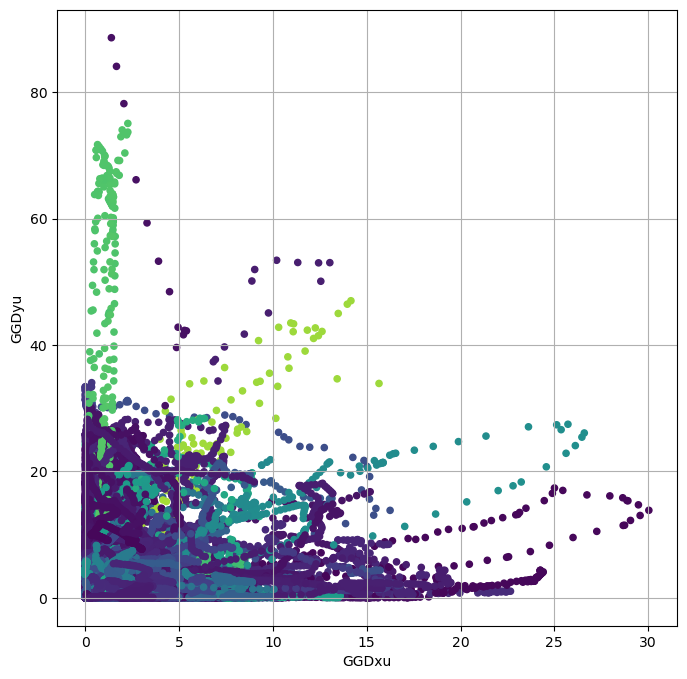

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dfswh['GGDxu'] = dfswh.ggdx**2/U2
dfswh['GGDyu'] = dfswh.ggdy**2/U2
dfswh['GGD'] = dfswh.GGDxu + dfswh.GGDyu
dfswh.plot.scatter('GGDxu', 'GGDyu', c = dfswh.swh_model, ax=ax)
ax.grid()

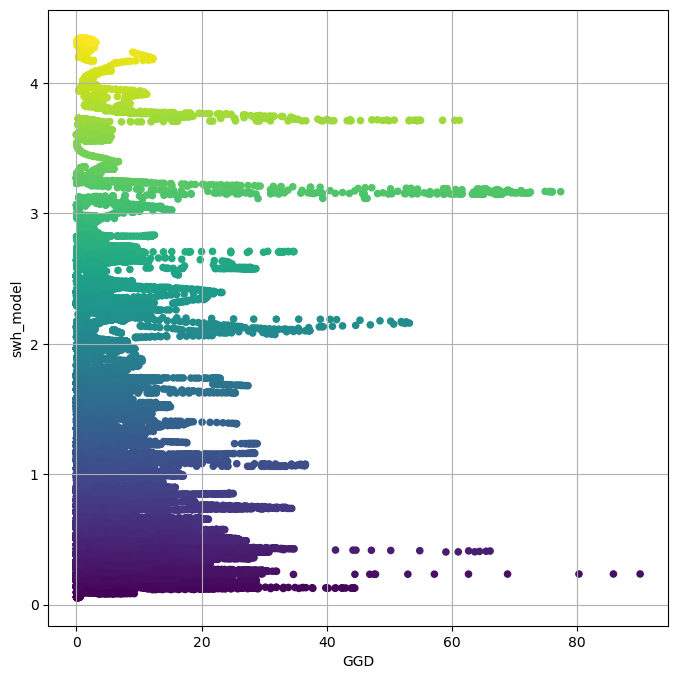

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dfswh.plot.scatter('GGD', 'swh_model', c = dfswh.swh_model, ax=ax)
ax.grid()

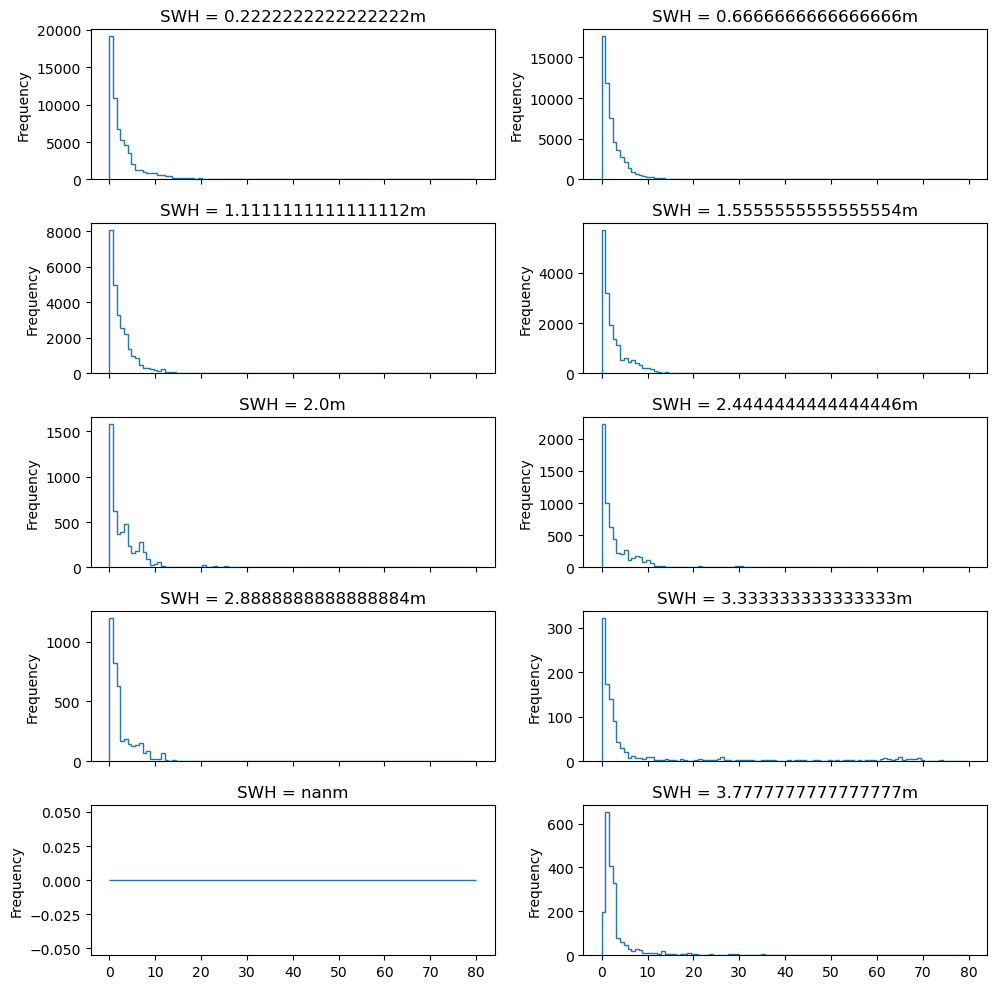

In [28]:
fig, axs = plt.subplots(5, 2, figsize=(10,10), frameon=False, sharex=True)
axs = axs.flatten()
i=0
for swh in sorted(dfswh.swh_model_cut.unique()) :
    ax=axs[i]
    df_ = dfswh[dfswh.swh_model_cut==swh]
    df_.GGD.plot.hist(bins = np.linspace(0,80,100), histtype='step', ax=ax)
    ax.set_title(f'SWH = {swh}m')
    i+=1

fig.tight_layout()
#dfswh.groupby('swh_model_cut').GGD.plot.hist(bins = np.linspace(0,80,100), histtype='step', subplots=False)

In [15]:
fig = plt.figure(figsize=(7,7), frameon=False)
ax = fig.add_subplot(111, projection=ccrs.Orthographic(3, 40.5))
ax.add_feature(cfeature.LAND,)
gl = ax.gridlines(draw_labels=True,)

dfswh[dfswh.GGD>30].plot.scatter('longitude', 'latitude', c='swh_model', ax=ax, transform=crs, s=1)

<GeoAxes: xlabel='longitude', ylabel='latitude'>

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Error in callback <function _draw_all_if_interactive at 0x2aaae3425790> (for post_execute):


URLError: <urlopen error [Errno 101] Network is unreachable>

URLError: <urlopen error [Errno 101] Network is unreachable>

<Figure size 700x700 with 2 Axes>

(0.0, 4.0)

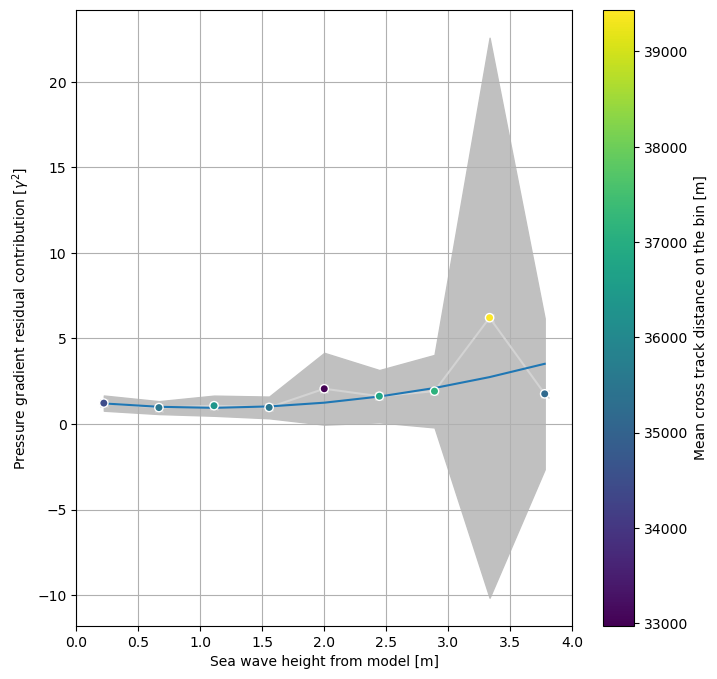

In [16]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['E_ggd'] = dsswh.Ex_ggd + dsswh.Ey_ggd
dsswh['er__E_ggd'] = dsswh.er__Ex_ggd + dsswh.er__Ey_ggd
dsswh.E_ggd.plot(ax=ax, marker = 'x', c='lightgrey')
plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='er__')
sc = dsswh.plot.scatter(x = 'swh_model_cut', y='E_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')

c = dsswh.where(dsswh.swh_model_cut<2).swh_model_cut
coef = np.polyfit(c, dsswh.E_ggd,2, w =dsswh.nb_coloc )
ax.plot(c, coef[0]*c**2  +coef[1]*c +coef[2])


ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')
ax.set_xlim(0, 4)

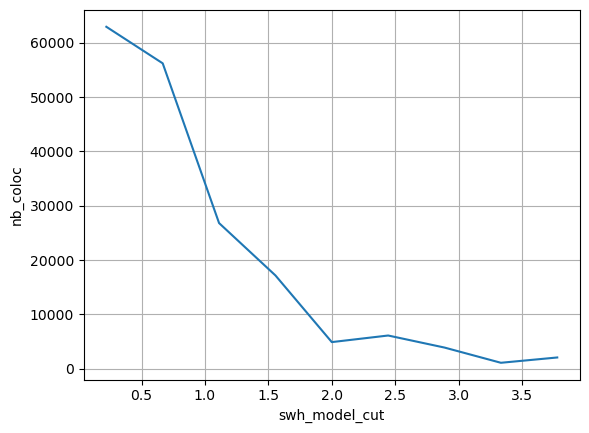

In [34]:
dsswh.nb_coloc.plot()
plt.grid()


Text(0.5, 0, 'Sea wave height from model [m]')

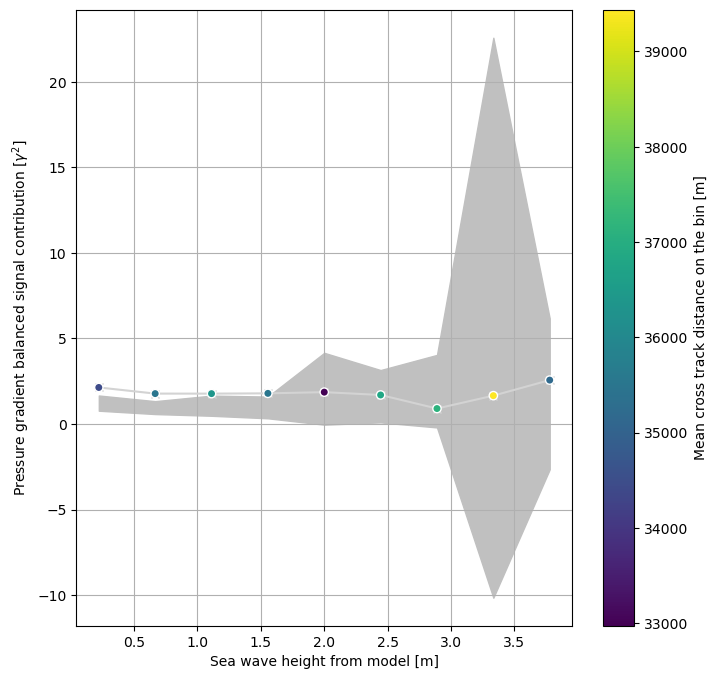

In [18]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['B_ggd'] = dsswh.Bx_ggd + dsswh.By_ggd
#dsswh['er__B_ggd'] = dsswh.er__Bx_ggd + dsswh.er__By_ggd
dsswh.B_ggd.plot(ax=ax, marker = 'x', c='lightgrey')
plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='er__')
sc = dsswh.plot.scatter(x = 'swh_model_cut', y='B_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')



ax.grid()
ax.set_ylabel(r'Pressure gradient balanced signal contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')

# Same-nb bins

In [12]:
compute_error = 'bootstrap'
n=25
dfswh = dfrr[(dfrr.abs_cross_track_distance>20e3) & (dfrr.abs_cross_track_distance<50e3)]
swh_dist_bins = np.array([float(dfswh.swh_model.quantile(i/n)) for i in range(n+1)])
dfswh['swh_model_cut'] = pd.cut(dfswh['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)
dsswh = compute_variance_groupby(dfswh, groupby = 'swh_model_cut', dirname = ('x', 'y'), compute_error =compute_error, vars_errors = ['Ex_ggd', 'Ey_ggd'] )
dsswh['meanbin_abs_cross_track_distance'] = dfswh.groupby('swh_model_cut', observed=False).abs_cross_track_distance.mean().dropna().to_xarray()
dsswh = dsswh.where(dsswh.nb_coloc>0).dropna('swh_model_cut')

/dev/shm/pbs.3496900.datarmor0/ipykernel_3320/1231384812.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['swh_model_cut'] = pd.cut(dfswh['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)
/home1/datahome/mdemol/med_analysis/diagnosis.py:619: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfm = (df.set_index(groupby)[[v+dirname[1] for v in var] + [v+dirname[0] for v in var]] - df.set_index(groupby)[[v+dirname[1] for v in var] + [v+dirname[0] for v in var]].groupby(groupby).mean()).reset_index()


swh_model_cut
0.112376    7561
0.190592    7561
0.229258    7562
0.270255    7561
0.309746    7562
0.344214    7561
0.372016    7561
0.400784    7562
0.436689    7561
0.476216    7562
0.509241    7561
0.544751    7562
0.591615    7561
0.651897    7561
0.719388    7562
0.793297    7561
0.884898    7561
1.002649    7562
1.114342    7561
1.218065    7562
1.396552    7561
1.595844    7561
1.880119    7562
2.374450    7561
3.506194    7562
Name: accx, dtype: int64
Ex_ggd
Ey_ggd


NameError: name 'freedom_degree' is not defined

(0.0, 4.0)

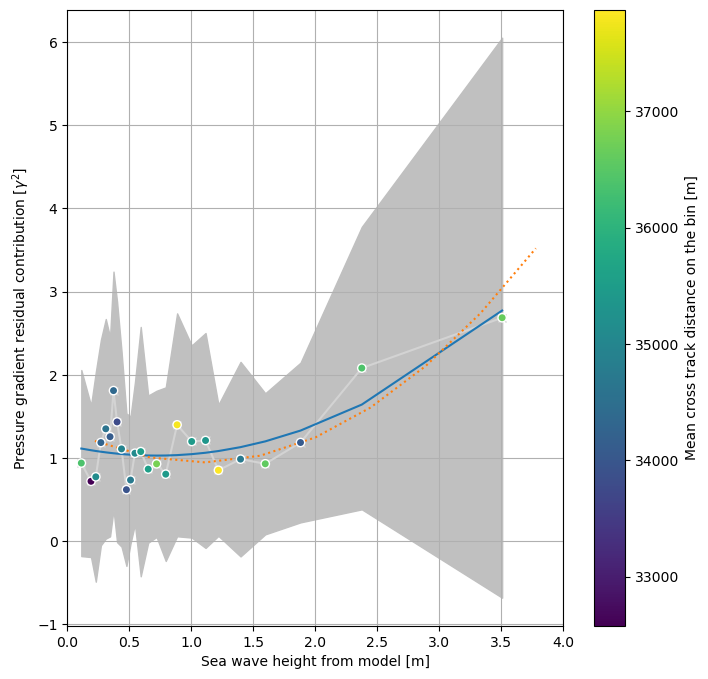

In [20]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['E_ggd'] = dsswh.Ex_ggd + dsswh.Ey_ggd
dsswh['er__E_ggd'] = dsswh.er__Ex_ggd + dsswh.er__Ey_ggd
dsswh.E_ggd.plot(ax=ax, marker = 'x', c='lightgrey')
plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='er__')
sc = dsswh.plot.scatter(x = 'swh_model_cut', y='E_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')

c1 = dsswh.where(dsswh.swh_model_cut<2).swh_model_cut
coef1 = np.polyfit(c1, dsswh.E_ggd,2, w =dsswh.nb_coloc )
ax.plot(c1, coef1[0]*c1**2  +coef1[1]*c1 +coef1[2])
ax.plot(c, coef[0]*c**2  +coef[1]*c +coef[2], ls=':')

ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')

ax.set_xlim(0, 4)

(0.0, 4.0)

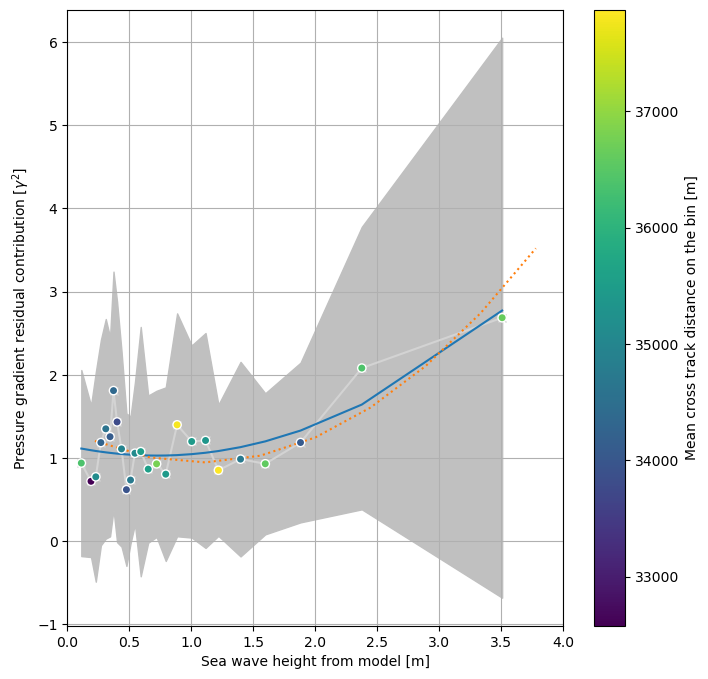

In [21]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['E_ggd'] = dsswh.Ex_ggd + dsswh.Ey_ggd
dsswh['er__E_ggd'] = dsswh.er__Ex_ggd + dsswh.er__Ey_ggd
dsswh.E_ggd.plot(ax=ax, marker = 'x', c='lightgrey')
plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='er__')
sc = dsswh.plot.scatter(x = 'swh_model_cut', y='E_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')

c1 = dsswh.where(dsswh.swh_model_cut<2).swh_model_cut
coef1 = np.polyfit(c1, dsswh.E_ggd,2, w =dsswh.nb_coloc )
ax.plot(c1, coef1[0]*c1**2  +coef1[1]*c1 +coef1[2])
ax.plot(c, coef[0]*c**2  +coef[1]*c +coef[2], ls=':')

ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')

ax.set_xlim(0, 4)

(6000.0, 7500.0)

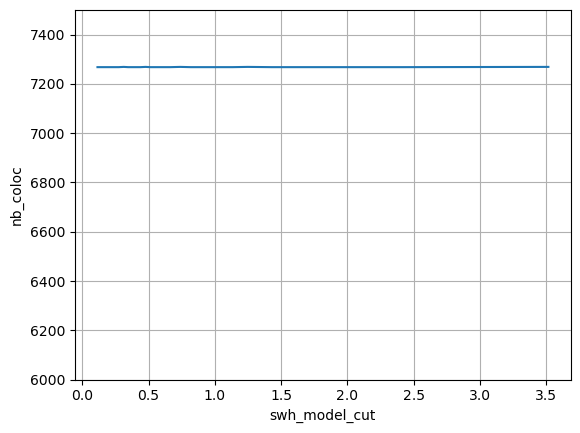

In [38]:
dsswh.nb_coloc.plot()
plt.grid()
plt.ylim(6000, 7500)

Text(0.5, 0, 'Sea wave height from model [m]')

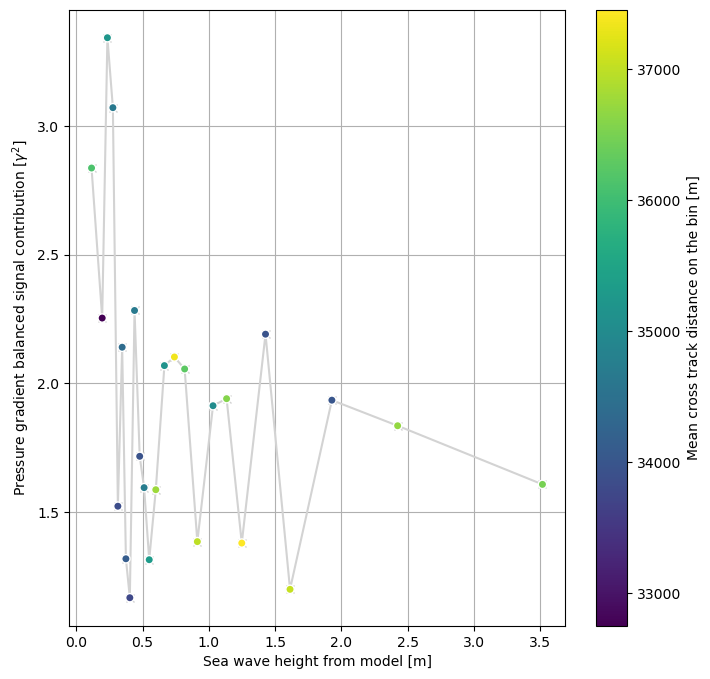

In [39]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['B_ggd'] = dsswh.Bx_ggd + dsswh.By_ggd
#dsswh['er__B_ggd'] = dsswh.er__Bx_ggd + dsswh.er__By_ggd
dsswh.B_ggd.plot(ax=ax, marker = 'x', c='lightgrey')
#plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='ber')
sc = dsswh.plot.scatter(x = 'swh_model_cut', y='B_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')



ax.grid()
ax.set_ylabel(r'Pressure gradient balanced signal contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')